# Spin-1/2 effective Hamiltonian

This notebook constructs an effective two-atom Hamiltonian for a spin-1/2 subspace encoded in two Yb174 Rydberg states.
It compares exact pair-interaction potentials from a full pair basis with the eigenvalues of an effective Hamiltonian obtained perturbatively.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pairinteraction.real as pi
from matplotlib import cm, colors
from pairinteraction.visualization.colormaps import alphamagma

if pi.Database.get_global_database() is None:
    pi.Database.initialize_global_database(download_missing=True)

The effective spin states are represented by a low-lying $S_0$ Rydberg state, labeled $|\downarrow\rangle$, and a nearby $P_1$ Rydberg state, labeled $|\uparrow\rangle$.
A single-atom basis is built around these target states, and the atomic Hamiltonian is diagonalized in a magnetic field of $20\,\mathrm{G}$ along the quantization axis.

In [2]:
kets = {
    "down": pi.KetAtom("Yb174_mqdt", nu=49.7, l=0, s=0, j=0, m=0),
    "up": pi.KetAtom("Yb174_mqdt", nu=50.1, l=1, s=0, j=1, m=0),
}
ket_labels = {"down": r"\downarrow", "up": r"\uparrow"}

basis_atom = pi.BasisAtom.from_kets(list(kets.values()), delta_nu=4, delta_l=2)
system_atom = pi.SystemAtom(basis_atom)
system_atom.set_magnetic_field([0, 0, -20], "G").set_diamagnetism_enabled(True)
system_atom.diagonalize()

SystemAtomReal(BasisAtomReal(|Yb174:S=0.0,nu=45.7,L=0.0,J=0,0⟩ ... |Yb174:S=0.0,nu=54.1,L=1.0,J=1,1⟩), is_diagonal=True)

The two-atom Hilbert space is split into three energetically separated spin subspaces: $|\downarrow\downarrow\rangle$, the exchange-coupled pair $|\uparrow\downarrow\rangle$ and $|\downarrow\uparrow\rangle$, and $|\uparrow\uparrow\rangle$.
For each subspace and a list of distances between the atoms, we build both the full pair system and a second-order effective pair system. The atoms are placed along the $z$ axis, so the distance vector is parallel to the quantization axis.

In [3]:
subspaces_labels = {
    "-1": [("down", "down")],
    "0": [("up", "down"), ("down", "up")],
    "+1": [("up", "up")],
}
subspaces = {
    key: [
        tuple(kets[label] for label in ket_pair_labels)
        for ket_pair_labels in ket_pair_labels_list
    ]
    for key, ket_pair_labels_list in subspaces_labels.items()
}
subspaces_energies_ghz = {
    key: sum(
        system_atom.get_corresponding_energy(kets[ket_key], unit="GHz")
        for ket_key in subspaces_labels[key][0]
    )
    for key in subspaces
}

bases_pair = {
    key: pi.BasisPair.from_kets(
        ket_pairs,
        (system_atom, system_atom),
        delta_energy=3,
        delta_energy_unit="GHz",
        delta_m=0,
    )
    for key, ket_pairs in subspaces.items()
}

distances_mum = np.linspace(3, 8, 100)
system_pair_lists: dict[str, list[pi.SystemPair]] = {}
eff_system_pair_lists: dict[str, list[pi.EffectiveSystemPair]] = {}
for key, basis_pair in bases_pair.items():
    system_pair_lists[key] = []
    eff_system_pair_lists[key] = []
    for distance in distances_mum:
        system_pair = pi.SystemPair(basis_pair)
        system_pair.set_distance_vector([0, 0, distance], "micrometer")
        system_pair_lists[key].append(system_pair)

        eff_system = pi.EffectiveSystemPair(subspaces[key])
        eff_system.set_perturbation_order(2)
        eff_system.system_pair = pi.SystemPair(basis_pair)
        eff_system.system_pair.set_distance_vector([0, 0, distance], "micrometer")
        eff_system_pair_lists[key].append(eff_system)

    pi.diagonalize(system_pair_lists[key])


energy0_pair_ghz = subspaces_energies_ghz["0"]

The plot shows the exact pair potentials in gray and colors each eigenstate by its total overlap with the target kets in the corresponding subspace.
The blue dashed curves are the eigenvalues calculated perturbatively from the effective Hamiltonian.

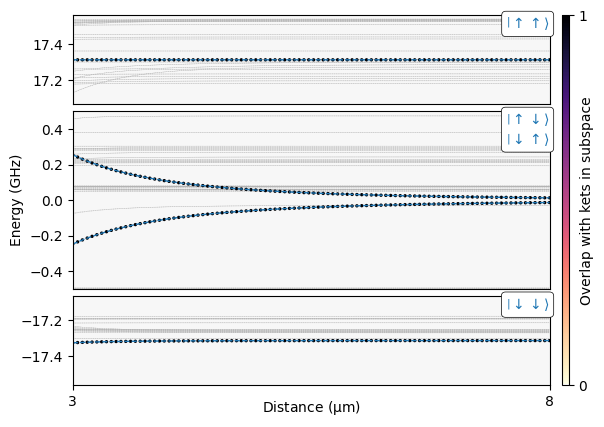

In [4]:
fig = plt.figure()

grid_columns = fig.add_gridspec(nrows=1, ncols=2, width_ratios=[2, 0.03], wspace=0.05)
cax = fig.add_subplot(grid_columns[0, 1])

ratios = [1, 2, 1]
grid_rows = grid_columns[0, 0].subgridspec(
    len(ratios), 1, height_ratios=ratios, hspace=0.02 * len(ratios)
)
axs = [fig.add_subplot(grid_rows[i, 0]) for i in range(len(ratios) - 1, -1, -1)]
for ax in axs:
    ax.set_facecolor("#f7f7f7")
sorted_keys = ["-1", "0", "+1"]
axs_dict = {key: axs[i] for i, key in enumerate(sorted_keys)}

# plot exact energy curves and overlap
for key, system_pair_list in system_pair_lists.items():
    energies_ghz = [
        system_pair.get_eigenenergies("GHz") - energy0_pair_ghz
        for system_pair in system_pair_list
    ]
    axs_dict[key].plot(distances_mum, energies_ghz, c="0.7", ls="--", lw=0.25, zorder=-10)

    overlaps = np.zeros_like(energies_ghz)
    for ket_pair in subspaces[key]:
        new_overlaps = [
            system_pair.get_eigenbasis().get_overlaps(ket_pair)
            for system_pair in system_pair_list
        ]
        overlaps += np.array(new_overlaps)

    x_repeated = np.hstack(
        [val * np.ones_like(es) for val, es in zip(distances_mum, energies_ghz, strict=True)]
    )
    energies_flattened = np.hstack(energies_ghz)
    overlaps_flattened = np.hstack(overlaps)
    sorter = np.argsort(overlaps_flattened)

    axs_dict[key].scatter(
        x_repeated[sorter],
        energies_flattened[sorter],
        c=overlaps_flattened[sorter],
        s=2,
        vmin=0,
        vmax=1,
        cmap=alphamagma,
    )

# colorbar
norm = colors.Normalize(vmin=0, vmax=1)
sm = cm.ScalarMappable(norm=norm, cmap=alphamagma)
cbar = fig.colorbar(sm, cax=cax, location="right")
cbar.set_ticks([0, 1])
cbar.set_label("Overlap with kets in subspace", rotation=90, labelpad=-5)

# effective hamiltonian curves
for key, eff_system_pair_list in eff_system_pair_lists.items():
    eff_h_list = [
        eff_system.get_effective_hamiltonian(unit="GHz") for eff_system in eff_system_pair_list
    ]
    eff_h_diag_list: list[np.ndarray] = []
    for eff_h in eff_h_list:
        eigval, eigvec = np.linalg.eigh(eff_h)
        eff_h_diag_list.append(eigval - energy0_pair_ghz)

    axs_dict[key].plot(distances_mum, eff_h_diag_list, ls="--", color="C0", lw=1)


# x axis
axs[0].set_xlabel(r"Distance ($\mathrm{\mu m}$)", labelpad=-7)
for iax, ax in enumerate(axs):
    ax.set_xlim(distances_mum[0], distances_mum[-1])
    if iax == 0:
        ax.set_xticks([distances_mum[0], distances_mum[-1]])
    else:
        ax.tick_params(labelbottom=False)
        ax.set_xticks([])

# y axis and lims
axs[len(axs) // 2].set_ylabel("Energy (GHz)")
energy_ranges = {key: 0.5 * ratios[i] for i, key in enumerate(sorted_keys)}
for key, energy_pair in subspaces_energies_ghz.items():
    energy_range = energy_ranges.get(key, 0.6)
    ymin = energy_pair - energy0_pair_ghz - energy_range / 2
    ymax = energy_pair - energy0_pair_ghz + energy_range / 2
    axs_dict[key].set_ylim(ymin, ymax)

# legend
bbox_kwargs = {"boxstyle": "round", "facecolor": "white", "alpha": 1, "linewidth": 0.5}
legend_kwargs = {"ha": "right", "va": "top", "color": "C0", "bbox": bbox_kwargs}
for key, label in subspaces_labels.items():
    legend_label = ""
    for i, labels in enumerate(label):
        ket_spin = rf"\left|{ket_labels[labels[0]]} {ket_labels[labels[1]]}\right\rangle"
        legend_label += rf"${ket_spin}$"
        if i < len(label) - 1:
            legend_label += "\n"

    axs_dict[key].text(1, 1, legend_label, transform=axs_dict[key].transAxes, **legend_kwargs)

plt.show()